# SSD (Single Shot Detector)

### Goal: 
**_Trained an SSD object detection model using TensorFlow with transfer learning, froze the backbone, fine-tuned the detection head, and evaluated it using mAP._**

**Big Picture Pipeline** = Dataset → TFRecord → SSD Model → Freeze Layers → Train → Evaluate → Inference

![](https://cdn-images-1.medium.com/max/1000/1*GmJiirxTSuSVrh-r7gtJdA.png)

**What parts does SSD have?**
1. Backbone (Feature Extractor)
   * Example: MobileNet / ResNet
   * Already trained on ImageNet
   * We will freeze this
1. Detection Head
   * Predicts:
   * Class probabilities
   * Bounding box coordinates

## Install required libraries

pip install tensorflow pillow lxml Cython contextlib2 matplotlib pandas opencv-python jupyter notebook

In [12]:
! pip list

Package                   Version
------------------------- -----------
absl-py                   2.3.1
anyio                     4.12.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
astunparse                1.6.3
async-lru                 2.0.5
attrs                     25.4.0
babel                     2.17.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2025.11.12
cffi                      2.0.0
charset-normalizer        3.4.4
colorama                  0.4.6
comm                      0.2.3
contextlib2               21.6.0
contourpy                 1.3.3
cycler                    0.12.1
Cython                    3.2.3
debugpy                   1.8.19
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
flatbuffers               25.12.19
fonttools                 4.61.1
fqdn         

In [13]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Num CPUs Available:", len(tf.config.list_physical_devices('CPU')))
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
Num CPUs Available: 1
GPUs: []


# Filter COCO JSON by Selected Classes

**Logic**
1. Load COCO JSON
2. Keep only categories we want
3. Keep only annotations using those category IDs
4. Keep only images referenced by remaining annotations
5. Save new JSON

In [14]:
import json
from pathlib import Path

## Filtering the Traning Data

### Selected COCO category IDs

In [15]:
SELECTED_CATEGORY_IDS = {1, 8, 18, 32, 43}

CATEGORY_ID_TO_NAME = {
    1: "person",
    8: "truck",
    18: "dog",
    32: "tie",
    43: "tennis racket"
}

### Load COCO annotation file

In [16]:
coco_json_path = Path("../data/annotations/instances_train2014.json")

with open(coco_json_path, "r") as f:
    coco_data = json.load(f)

print("Total images:", len(coco_data["images"]))
print("Total annotations:", len(coco_data["annotations"]))
print("Total categories:", len(coco_data["categories"]))

Total images: 82783
Total annotations: 604907
Total categories: 80


### filter categiries

In [17]:
filtered_categories = [
    cat for cat in coco_data["categories"]
    if cat["id"] in SELECTED_CATEGORY_IDS
]

print("Filtered categories:")
for cat in filtered_categories:
    print(cat["id"], cat["name"])

Filtered categories:
1 person
8 truck
18 dog
32 tie
43 tennis racket


### Filter annotations

In [18]:
filtered_annotations = [
    ann for ann in coco_data["annotations"]
    if ann["category_id"] in SELECTED_CATEGORY_IDS
]

print("Filtered annotations:", len(filtered_annotations))

Filtered annotations: 204048


### Filter images

In [19]:
# Get image IDs that still have valid annotations
valid_image_ids = set(ann["image_id"] for ann in filtered_annotations)

filtered_images = [
    img for img in coco_data["images"]
    if img["id"] in valid_image_ids
]

print("Filtered images:", len(filtered_images))

Filtered images: 48337


### Create new filtered COCO JSON

In [20]:
filtered_coco = {
    "images": filtered_images,
    "annotations": filtered_annotations,
    "categories": filtered_categories
}

### Save filtered JSON

In [21]:
output_path = Path("../data/annotations/train_filtered.json")

with open(output_path, "w") as f:
    json.dump(filtered_coco, f)

print("Saved filtered COCO annotations to:", output_path)

Saved filtered COCO annotations to: ..\data\annotations\train_filtered.json


## Filtering the validation Data

### Load COCO annotation file

In [22]:
from pathlib import Path
import json

val_json_path = Path("../data/annotations/instances_val2014.json")

with open(val_json_path, "r") as f:
    coco_val = json.load(f)

print("Total validation images:", len(coco_val["images"]))
print("Total validation annotations:", len(coco_val["annotations"]))
print("Total categories:", len(coco_val["categories"]))

Total validation images: 40504
Total validation annotations: 291875
Total categories: 80


### Filter categiries

In [25]:
filtered_val_categories=[
    cat for cat in coco_val["categories"]
    if cat["id"] in SELECTED_CATEGORY_IDS
]

print("Filtered val categories:")
for cat in filtered_val_categories:
    print(cat["id"], cat["name"])

Filtered val categories:
1 person
8 truck
18 dog
32 tie
43 tennis racket


### Filter annotations

In [26]:
filtered_val_annotations = [
    ann for ann in coco_val["annotations"]
    if ann["category_id"] in SELECTED_CATEGORY_IDS
]

print("filtered_val_annotations =",len(filtered_val_annotations))

filtered_val_annotations = 97322


### Filter images

In [27]:
valid_val_image_ids = set(ann["image_id"] for ann in filtered_val_annotations)

filtered_val_images = [
    img for img in coco_val["images"]
    if img["id"] in valid_val_image_ids
]

print("Filtered images:", len(filtered_val_images))

Filtered images: 23231


### Create new filtered COCO JSON

In [29]:
val_filtered_coco = {
    "images": filtered_val_images,
    "annotations": filtered_val_annotations,
    "categories": filtered_val_categories
}

### Save filtered JSON

In [30]:
output_val_path=Path("../data/annotations/val_filtered.json")

with open(output_val_path,"w") as f:
    json.dump(val_filtered_coco,f)

print("Saved filtered validation annotations to:", output_val_path)

Saved filtered validation annotations to: ..\data\annotations\val_filtered.json


# Convert COCO JSON to TFRecord

* SSD cannot train on JSON
* TensorFlow requires TFRecord
* This step teaches you:
  * Bounding box normalization
  * Class ID remapping
  * Data pipelines    
(**TFRecord** _is a fast, optimized container that stores image + bounding boxes + labels together._ )

**COCO bounding box format** = _[x_min, y_min, width, height]  ==> (pixels)_  
**SSD / TF expects** = _[xmin, ymin, xmax, ymax]  ==>  (normalized 0–1)_  

So we convert like this:
```python
xmax = (x_min + width) / image_width
ymax = (y_min + height) / image_height
xmin = x_min / image_width
ymin = y_min / image_height
```

## Imports, Paths & label map

In [31]:
import tensorflow as tf
import json
from pathlib import Path
from PIL import Image
import io

IMAGES_DIR = Path("../data/images/train")
ANNOTATION_PATH = Path("../data/annotations/train_filtered.json")
OUTPUT_TFRECORD = Path("../data/train.record")

# COCO → SSD label remap
LABEL_MAP = {
    1: 1,    # person
    8: 2,    # truck
    18: 3,   # dog
    32: 4,   # tie
    43: 5    # tennis racket
}

## Helper functions

In [32]:
def bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def int64_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def float_list_feature(value):
    return tf.train.Feature(float_list=tf.train.FloatList(value=value))

def int64_list_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=value))

## Load annotations

In [35]:
with open(ANNOTATION_PATH, "r") as f:
    coco = json.load(f)

# Group annotations by image_id
annotations_by_image = {}
for ann in coco["annotations"]:
    annotations_by_image.setdefault(ann["image_id"], []).append(ann)

print("Images:", len(coco["images"]))
print("Annotations:", len(coco["annotations"]))

Images: 48337
Annotations: 204048


## TFRecord writer

In [36]:
writer = tf.io.TFRecordWriter(str(OUTPUT_TFRECORD))

for img in coco["images"]:
    image_id = img["id"]
    image_path = IMAGES_DIR / img["file_name"]

    if image_id not in annotations_by_image:
        continue

    # Read image
    with open(image_path, "rb") as f:
        encoded_image = f.read()

    image = Image.open(io.BytesIO(encoded_image))
    width, height = image.size

    xmins, xmaxs, ymins, ymaxs = [], [], [], []
    labels = []

    for ann in annotations_by_image[image_id]:
        x, y, w, h = ann["bbox"]

        xmin = x / width
        ymin = y / height
        xmax = (x + w) / width
        ymax = (y + h) / height

        xmins.append(xmin)
        ymins.append(ymin)
        xmaxs.append(xmax)
        ymaxs.append(ymax)

        labels.append(LABEL_MAP[ann["category_id"]])

    example = tf.train.Example(features=tf.train.Features(feature={
        "image/height": int64_feature(height),
        "image/width": int64_feature(width),
        "image/encoded": bytes_feature(encoded_image),
        "image/format": bytes_feature(b"jpeg"),
        "image/object/bbox/xmin": float_list_feature(xmins),
        "image/object/bbox/xmax": float_list_feature(xmaxs),
        "image/object/bbox/ymin": float_list_feature(ymins),
        "image/object/bbox/ymax": float_list_feature(ymaxs),
        "image/object/class/label": int64_list_feature(labels),
    }))

    writer.write(example.SerializeToString())

writer.close()

print("TFRecord created:", OUTPUT_TFRECORD)


TFRecord created: ..\data\train.record


## (for validation) Convert COCO JSON to TFRecord

In [37]:
IMAGES_DIR_VAL = Path("../data/images/val")
ANNOTATION_PATH_VAL = Path("../data/annotations/val_filtered.json")
OUTPUT_VAL_TFRECORD = Path("../data/val.record")


# ------------------------------------------------------------------------------------------------
# ------------------------------------------------------------------------------------------------
with open(ANNOTATION_PATH_VAL, "r") as f:
    coco_val = json.load(f)

annotations_by_image_val = {}
for ann in coco_val["annotations"]:
    annotations_by_image_val.setdefault(ann["image_id"], []).append(ann)

print("Validation images:", len(coco_val["images"]))
print("Validation annotations:", len(coco_val["annotations"]))


# ------------------------------------------------------------------------------------------------
# ------------------------------------------------------------------------------------------------
writer = tf.io.TFRecordWriter(str(OUTPUT_VAL_TFRECORD))

for img in coco_val["images"]:
    image_id = img["id"]
    image_path = IMAGES_DIR_VAL / img["file_name"]

    if image_id not in annotations_by_image_val:
        continue

    with open(image_path, "rb") as f:
        encoded_image = f.read()

    image = Image.open(io.BytesIO(encoded_image))
    width, height = image.size

    xmins, xmaxs, ymins, ymaxs = [], [], [], []
    labels = []

    for ann in annotations_by_image_val[image_id]:
        x, y, w, h = ann["bbox"]

        xmin = x / width
        ymin = y / height
        xmax = (x + w) / width
        ymax = (y + h) / height

        xmins.append(xmin)
        ymins.append(ymin)
        xmaxs.append(xmax)
        ymaxs.append(ymax)

        labels.append(LABEL_MAP[ann["category_id"]])

    example = tf.train.Example(features=tf.train.Features(feature={
        "image/height": int64_feature(height),
        "image/width": int64_feature(width),
        "image/encoded": bytes_feature(encoded_image),
        "image/format": bytes_feature(b"jpeg"),
        "image/object/bbox/xmin": float_list_feature(xmins),
        "image/object/bbox/xmax": float_list_feature(xmaxs),
        "image/object/bbox/ymin": float_list_feature(ymins),
        "image/object/bbox/ymax": float_list_feature(ymaxs),
        "image/object/class/label": int64_list_feature(labels),
    }))

    writer.write(example.SerializeToString())

writer.close()

print("Validation TFRecord created:", OUTPUT_VAL_TFRECORD)

Validation images: 23231
Validation annotations: 97322
Validation TFRecord created: ..\data\val.record


# Visualize data

In [38]:
feature_description = {
    "image/height": tf.io.FixedLenFeature([], tf.int64),
    "image/width": tf.io.FixedLenFeature([], tf.int64),
    "image/encoded": tf.io.FixedLenFeature([], tf.string),
    "image/format": tf.io.FixedLenFeature([], tf.string),
    "image/object/bbox/xmin": tf.io.VarLenFeature(tf.float32),
    "image/object/bbox/xmax": tf.io.VarLenFeature(tf.float32),
    "image/object/bbox/ymin": tf.io.VarLenFeature(tf.float32),
    "image/object/bbox/ymax": tf.io.VarLenFeature(tf.float32),
    "image/object/class/label": tf.io.VarLenFeature(tf.int64),
}

In [40]:
def _parse_example(example_proto):
    return tf.io.parse_single_example(example_proto, feature_description)

dataset = tf.data.TFRecordDataset("../data/train.record")
parsed = dataset.map(_parse_example)

for example in parsed.take(1):
    print("Keys in TFRecord:")
    for key in example:
        print(" ", key)

Keys in TFRecord:
  image/object/bbox/xmax
  image/object/bbox/xmin
  image/object/bbox/ymax
  image/object/bbox/ymin
  image/object/class/label
  image/encoded
  image/format
  image/height
  image/width


## Visualize image + bounding boxes

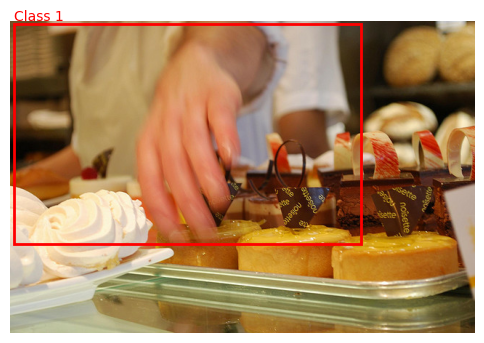

In [42]:
import matplotlib.pyplot as plt
import numpy as np

for example in parsed.take(1):
    image = tf.image.decode_jpeg(example["image/encoded"])
    h = example["image/height"].numpy()
    w = example["image/width"].numpy()

    xmins = tf.sparse.to_dense(example["image/object/bbox/xmin"]).numpy()
    xmaxs = tf.sparse.to_dense(example["image/object/bbox/xmax"]).numpy()
    ymins = tf.sparse.to_dense(example["image/object/bbox/ymin"]).numpy()
    ymaxs = tf.sparse.to_dense(example["image/object/bbox/ymax"]).numpy()
    labels = tf.sparse.to_dense(example["image/object/class/label"]).numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")

    for xmin, ymin, xmax, ymax, label in zip(xmins, ymins, xmaxs, ymaxs, labels):
        xmin *= w
        xmax *= w
        ymin *= h
        ymax *= h

        plt.gca().add_patch(
            plt.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                fill=False,
                edgecolor="red",
                linewidth=2
            )
        )
        plt.text(xmin, ymin - 5, f"Class {label}", color="red")

    plt.show()


# SSD Model Setup

Create **label_map.pbtxt**  
ssd_object_detection/  
└── data/    
 .   .    └── label_map.pbtxt  

In [45]:
# write the following to map the catagories
with open("../data/label_map.pbtxt") as f:
    print(f.read())

item {
  id: 1
  name: 'person'
}

item {
  id: 2
  name: 'truck'
}

item {
  id: 3
  name: 'dog'
}

item {
  id: 4
  name: 'tie'
}

item {
  id: 5
  name: 'tennis racket'
}


## Downloading the model

In [52]:
import os
import urllib.request

# Corrected URL with the date path included
MODEL_URL = "http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz"

# Path logic
DEST_DIR = "../models/pretrained"
FILE_NAME = "ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz"
DOWNLOAD_PATH = os.path.join(DEST_DIR, FILE_NAME)

# Create the directory if it doesn't exist
if not os.path.exists(DEST_DIR):
    os.makedirs(DEST_DIR)
    print(f"Created directory: {DEST_DIR}")

print("Downloading model... this may take a moment.")
try:
    opener = urllib.request.build_opener()
    opener.addheaders = [('User-agent', 'Mozilla/5.0')]
    urllib.request.install_opener(opener)
    
    urllib.request.urlretrieve(MODEL_URL, DOWNLOAD_PATH)
    print(f"Download complete! Saved to: {DOWNLOAD_PATH}")
except Exception as e:
    print(f"An error occurred: {e}")

Download complete! Saved to: ../models/pretrained\ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz


## Extract the model

In [53]:
import tarfile

tar_path = DOWNLOAD_PATH
extract_path = "../models/pretrained"

with tarfile.open(tar_path) as tar:
    tar.extractall(path=extract_path)

print("Extraction complete!")

Extraction complete!


## Verify folder structure

In [1]:
import os

print(os.listdir("../models/pretrained"))
print(os.listdir("../models/pretrained/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8"))

['ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8', 'ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz']
['checkpoint', 'pipeline.config', 'saved_model']


# Load the model

In [1]:
import tensorflow as tf

MODEL_DIR = "../models_loaded/pretrained/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/saved_model"

print("Loading model...")
detect_fn = tf.saved_model.load(MODEL_DIR)
print("Model loaded successfully!")

Loading model...
Model loaded successfully!


In [2]:
# Inspect model signatures
detect_fn.signatures

_SignatureMap({'serving_default': <ConcreteFunction signature_wrapper(input_tensor) at 0x23168186C80>})

This tells us:
* The model expects an image tensor
* It outputs:
  * bounding boxes
  * class IDs
  * confidence scores

## Run a dummy inference
it is done to **check**  weather the model is working or not

In [3]:
import numpy as np

dummy_image = tf.convert_to_tensor(
    np.zeros((1, 320, 320, 3), dtype=np.uint8)
)

output = detect_fn(dummy_image)

for key, value in output.items():
    print(key, value.shape)

detection_anchor_indices (1, 100)
num_detections (1,)
detection_boxes (1, 100, 4)
raw_detection_boxes (1, 12804, 4)
detection_classes (1, 100)
detection_scores (1, 100)
raw_detection_scores (1, 12804, 91)
detection_multiclass_scores (1, 100, 91)


# FREEZE and TRAIN

```python
Input Image
   ↓
MobileNetV2 Backbone   ← FREEZE ❄️
   ↓
FPN Layers             ← FREEZE ❄️
   ↓
Box Predictor Head     ← TRAIN 🔥
Class Predictor Head   ← TRAIN 🔥
```
Freezing & fine-tuning is controlled via 👉 **pipeline.config** not by **model.trainable = False**

In [1]:
!python model_main_tf2.py \
  --model_dir=../models/my_custom_ssd_model \
  --pipeline_config_path=../models/pretrained/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/pipeline.config \
  --num_train_steps=5000 \
  --alsologtostderr

python: can't open file 'D:\\machine learning\\Artificial intelligence\\large projects\\Yolo segmentation\\notebooks\\model_main_tf2.py': [Errno 2] No such file or directory
